# 1. Executive Summary
Emergency Departments (EDs) experience operational and financial strain when patients leave without being seen (LWBS), resulting in lost revenue, reduced patient satisfaction, and potential safety concerns. This analysis identifies operational and temporal drivers associated with LWBS and develops a predictive model to detect high-risk encounters before provider evaluation. Exploratory analysis revealed that prolonged intake delays, staffing strain, and low-acuity patient mix are strongly associated with LWBS events. A logistic regression model achieved an ROC-AUC of 0.87, demonstrating strong predictive performance using pre-provider operational variables. These findings support targeted workflow interventions to reduce LWBS by at least 15% during high-volume periods.

# 2. Buisness Problem & SMART Objective
## Business Context
Emergency Departments are experiencing elevated Left Without Being Seen (LWBS) rates, negatively impacting revenue, patient safety, and patient satisfaction.

## Project Objective
Identify key operational drivers associated with LWBS and develop a predictive model capable of identifying high-risk encounters prior to provider evaluation.

## Target Outcome
Achieve a **15% relative reduction in LWBS** over the next 12 months through predictive analytics and operational modeling.


# 3. Data Overview

In [81]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Modeling + evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("ER Wait Time Dataset.csv")

print("Rows, Columns:", df.shape)
display(df.head())
df.info()

Rows, Columns: (5000, 19)


,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Visit ID                            5000 non-null   object
 1   Patient ID                          5000 non-null   object
 2   Hospital ID                         5000 non-null   object
 3   Hospital Name                       5000 non-null   object
 4   Region                              5000 non-null   object
 5   Visit Date                          5000 non-null   object
 6   Day of Week                         5000 non-null   object
 7   Season                              5000 non-null   object
 8   Time of Day                         5000 non-null   object
 9   Urgency Level                       5000 non-null   object
 10  Nurse-to-Patient Ratio              5000 non-null   int64 
 11  Specialist Availability             5000 non-null   int6

In [82]:
# Create target: 1 if patient left without being seen, else 0
df["LWBS"] = df["Patient Outcome"].eq("Left Without Being Seen").astype(int)

# Baseline metrics
n_visits = len(df)
n_lwbs = int(df["LWBS"].sum())
lwbs_rate = df["LWBS"].mean()

print(f"Baseline LWBS Rate: {lwbs_rate:.2%} ({n_lwbs} of {n_visits} visits)")

Baseline LWBS Rate: 5.06% (253 of 5000 visits)


**Data at a glance**
- Records: 5,000 ED visits
- Target: LWBS (derived from Patient Outcome)
- Baseline: 5.06% (~253 LWBS visits)
- Features: operational timing (registration, triage), staffing variables, hospital characteristics, temporal indicators, and urgency level
- Data quality: no material missingness observed
- Goal translation: a 15% relative reduction from 5.06% implies a target LWBS rate of ~4.30%

# 4. Exploritory Data Analysis

## Baseline LWBS Volume & Rates

To establish context, we first examine overall LWBS volume and baseline rate. This provides a benchmark against which temporal and operational patterns can be evaluated.

In [83]:
total_visits = len(df)
total_lwbs = int(df["LWBS"].sum())
baseline_rate = df["LWBS"].mean()

print(f"Total Visits: {total_visits}")
print(f"Total LWBS: {total_lwbs}")
print(f"Baseline LWBS Rate: {baseline_rate:.2%}")

Total Visits: 5000
Total LWBS: 253
Baseline LWBS Rate: 5.06%


In [84]:
# Ensure Visit Date is datetime
df["Visit Date"] = pd.to_datetime(df["Visit Date"])

# Create time features
df["Day_of_Week"] = df["Visit Date"].dt.day_name()
df["Visit_Week"] = df["Visit Date"].dt.to_period("W")
df["Visit_Month"] = df["Visit Date"].dt.to_period("M")

# Calculate averages
weekly_avg = df.groupby("Visit_Week")["LWBS"].sum().mean()
monthly_avg = df.groupby("Visit_Month")["LWBS"].sum().mean()

print("Average LWBS per Week:", round(weekly_avg, 2))
print("Average LWBS per Month:", round(monthly_avg, 2))

Average LWBS per Week: 4.77
Average LWBS per Month: 21.08


On average, the department experiences approximately 4–5 LWBS cases per week and ~21 per month. While the baseline rate appears low at ~5%, the absolute volume translates to consistent operational loss over time. This suggests even modest percentage reductions may yield meaningful annual impact.

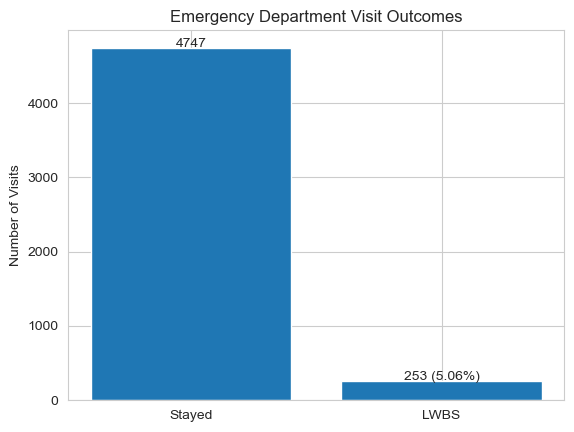

In [85]:
labels = ['Stayed', 'LWBS']
counts = [total_visits - total_lwbs, total_lwbs]

plt.figure()

bars = plt.bar(labels, counts)

plt.title('Emergency Department Visit Outcomes')
plt.ylabel('Number of Visits')

# Annotate counts and percentage
for i, v in enumerate(counts):
    if labels[i] == 'LWBS':
        plt.text(i, v + 20, f'{v} ({baseline_rate:.2%})', ha='center')
    else:
        plt.text(i, v + 20, f'{v}', ha='center')

plt.show()

## Temporal LWBS Patterns

While the overall LWBS rate provides a baseline, operational strain is rarely uniform throughout the day. Emergency Departments experience fluctuations in volume, staffing transitions, and patient acuity across hours and days. To identify high-risk windows, we examine LWBS rates across time-of-day and calendar dimensions. Understanding when departures peak is critical for targeted operational intervention.

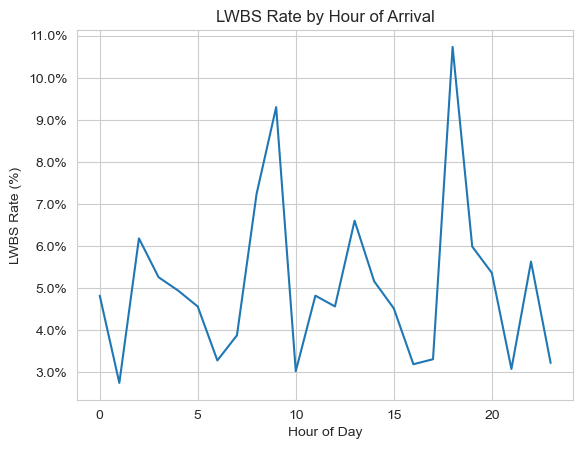

In [86]:
# Ensure Visit Date is datetime
df["Visit Date"] = pd.to_datetime(df["Visit Date"], errors="coerce")

# Create Arrival_Hour
df["Arrival_Hour"] = df["Visit Date"].dt.hour

hour_summary = (
    df.groupby("Arrival_Hour")["LWBS"]
      .mean()
      .reset_index()
)

plt.figure()

plt.plot(hour_summary["Arrival_Hour"],
         hour_summary["LWBS"])

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title("LWBS Rate by Hour of Arrival")
plt.xlabel("Hour of Day")
plt.ylabel("LWBS Rate (%)")

plt.show()

Temporal analysis revealed elevated LWBS rates during specific hours of the day, with peaks around **9 AM and 6 PM**, corresponding to common shift transitions and high-volume periods. Secondary increases were observed during midday and early morning hours. These patterns suggest that staffing transitions and throughput surges may temporarily reduce operational efficiency, increasing the likelihood of patients leaving prior to provider evaluation.

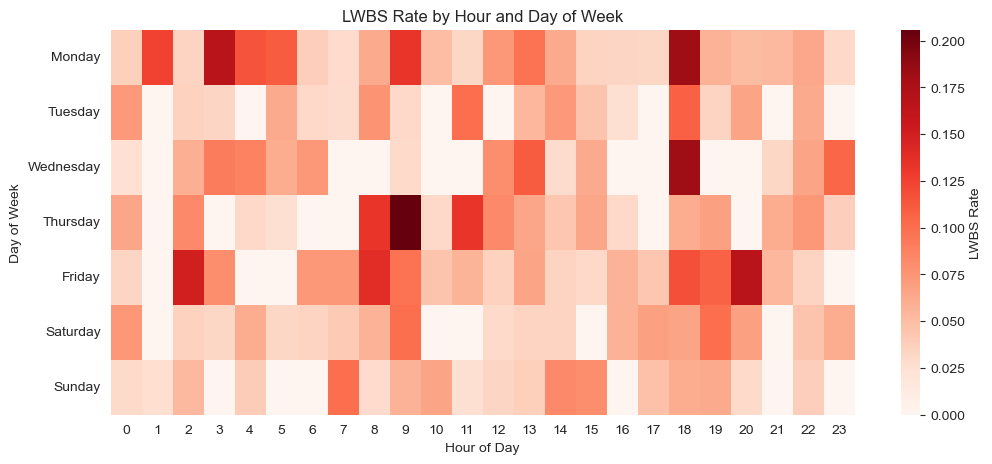

In [87]:
# Create time variables
df["Visit Date"] = pd.to_datetime(df["Visit Date"], errors="coerce")
df["Arrival_Hour"] = df["Visit Date"].dt.hour
df["Day_of_Week"] = df["Visit Date"].dt.day_name()

# Order days properly
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# Compute LWBS rate
heatmap_data = (
    df.groupby(["Day_of_Week","Arrival_Hour"])["LWBS"]
      .mean()
      .unstack()
)

heatmap_data = heatmap_data.reindex(day_order)

# Plot heatmap
plt.figure(figsize=(12,5))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    cbar_kws={"label":"LWBS Rate"}
)

plt.title("LWBS Rate by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

The heatmap further illustrates how LWBS risk varies across both hour of day and day of week. Elevated LWBS rates consistently appear during morning and evening transition periods, particularly around 9 AM and 6 PM, supporting the hypothesis that shift transitions and throughput surges contribute to temporary operational strain. Weekday patterns show more pronounced variability compared to weekends, suggesting that higher patient volumes and staffing adjustments during standard business days may amplify these effects. These temporal patterns highlight specific windows where targeted staffing or fast-track interventions could reduce LWBS risk.

## Operational & Patient Drivers of LWBS

After identifying temporal patterns, the next step is to evaluate operational and patient-level drivers associated with LWBS events. Because certain variables (such as total wait time) are partially determined after provider evaluation, we exclude leakage features to ensure insights reflect pre-departure operational conditions. This section explores correlations and group-level differences to identify actionable predictors of patient departure.

In [88]:
df_model = df.copy()

# Drop leakage columns
drop_cols = [
    "Visit ID",
    "Patient ID",
    "Hospital ID",
    "Hospital Name",
    "Patient Satisfaction",
    "Patient Outcome"
]

df_model = df_model.drop(columns=drop_cols)

# Drop Period columns
df_model = df_model.select_dtypes(include=["number", "object"])

# Ensure LWBS numeric
df_model["LWBS"] = df_model["LWBS"].astype(int)

# Identify categorical columns
categorical_cols = df_model.select_dtypes(include="object").columns

# One-hot encode as integers
df_encoded = pd.get_dummies(
    df_model,
    columns=categorical_cols,
    drop_first=False,
    dtype=int
)

# Now correlation works
correlations = df_encoded.corr()["LWBS"].sort_values(ascending=False)

correlations.head(7)

LWBS                                  1.000000
Total Wait Time (min)                 0.329384
Time to Triage (min)                  0.324039
Time to Medical Professional (min)    0.313935
Time to Registration (min)            0.307058
Urgency Level_Low                     0.289138
Nurse-to-Patient Ratio                0.212577
Name: LWBS, dtype: float64

Correlation analysis indicates that intake-related delays—particularly time to triage (r = 0.32) and time to medical professional (r = 0.31)—exhibit the strongest positive associations with LWBS. Total wait time shows a similar magnitude (r = 0.33); however, it is excluded from modeling due to potential leakage, as it is partially determined by whether a patient ultimately receives care. Nurse-to-patient ratio and low-acuity classification also demonstrate moderate positive relationships, suggesting both operational strain and patient urgency mix contribute to departure risk.

In [89]:
df_encoded.groupby("LWBS")[[
    "Time to Registration (min)",
    "Time to Triage (min)",
    "Time to Medical Professional (min)",
    "Nurse-to-Patient Ratio",
    "Urgency Level_Low"
]].mean()


,Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Nurse-to-Patient Ratio,Urgency Level_Low
LWBS,,,,,
0,10.964399,22.971350,42.804087,3.179271,0.215715
1,25.584980,59.644269,93.818182,4.343874,0.782609


Patients who left without being seen experienced substantially longer intake delays across all stages. On average, LWBS patients waited:

- 2.3× longer for registration (25.6 vs 11.0 minutes)

- 2.6× longer for triage (59.6 vs 23.0 minutes)

- 2.2× longer to see a medical professional (93.8 vs 42.8 minutes)

Additionally, 78% of LWBS patients were classified as low urgency, compared to 22% among completed encounters. These findings suggest that prolonged triage delays and low-acuity presentations are key contributors to patient departure behavior.

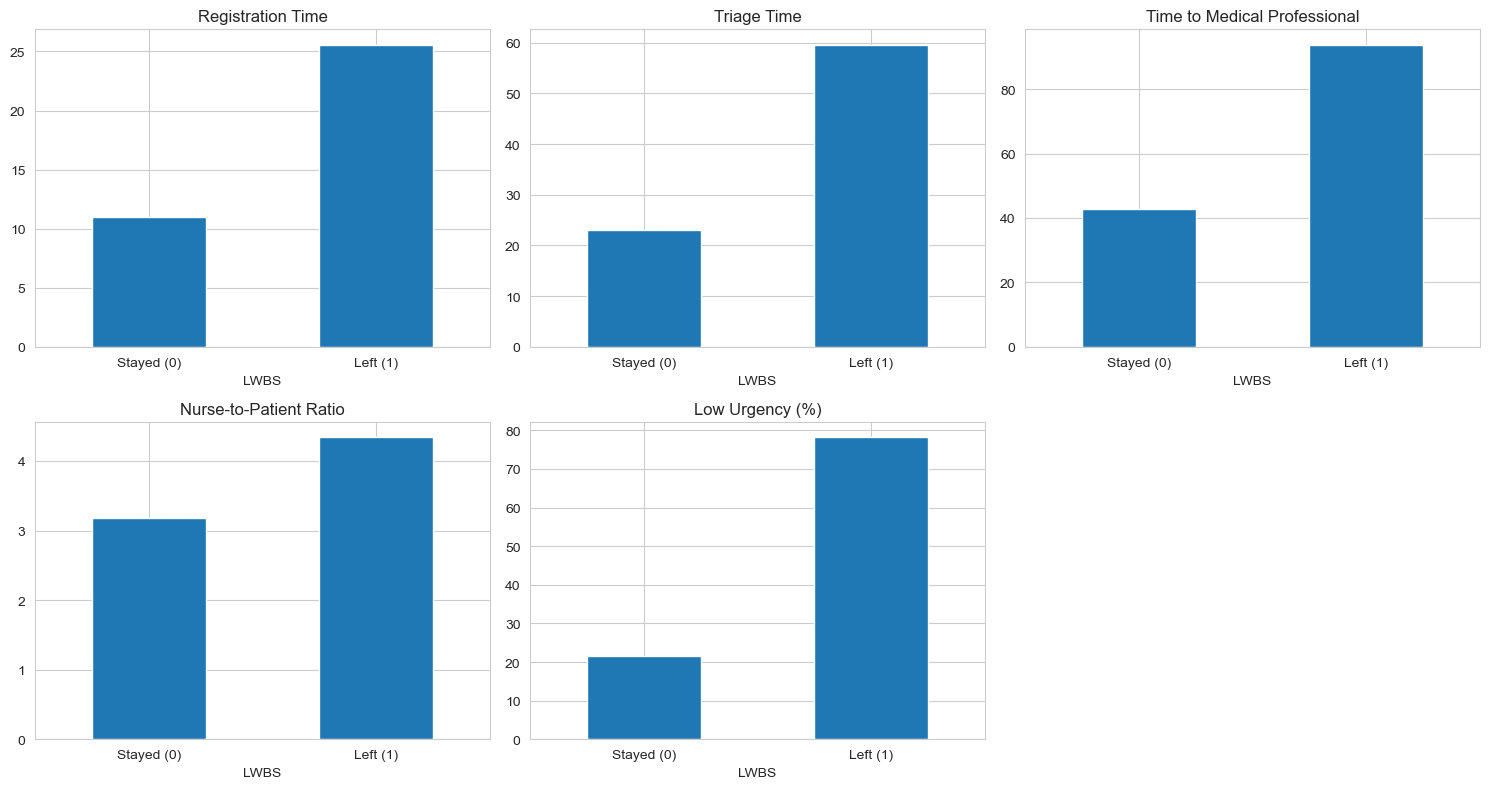

In [90]:
# Create grouped summary
df_summary = df_encoded.groupby("LWBS")[[
    "Time to Registration (min)",
    "Time to Triage (min)",
    "Time to Medical Professional (min)",
    "Nurse-to-Patient Ratio",
    "Urgency Level_Low"
]].mean()

# Convert urgency to percentage
df_summary["Urgency Level_Low"] *= 100

# Create subplot grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

metrics = [
    "Time to Registration (min)",
    "Time to Triage (min)",
    "Time to Medical Professional (min)",
    "Nurse-to-Patient Ratio",
    "Urgency Level_Low"
]

titles = [
    "Registration Time",
    "Triage Time",
    "Time to Medical Professional",
    "Nurse-to-Patient Ratio",
    "Low Urgency (%)"
]

# Flatten axes for easy iteration
axes = axes.flatten()

for i, metric in enumerate(metrics):
    df_summary[metric].plot(kind="bar", ax=axes[i])
    axes[i].set_title(titles[i])
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(["Stayed (0)", "Left (1)"], rotation=0)

# Remove the unused 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

Patients who left without being seen experienced substantially longer delays across all intake stages. On average, LWBS patients waited approximately **26 minutes for registration, 60 minutes for triage, and 94 minutes to see a medical professional**, compared to **11, 23, and 43 minutes respectively** for patients who completed care. This represents an additional **15 minutes at registration, 37 minutes at triage, and over 50 additional minutes before provider contact**. These findings suggest that cumulative process delays, rather than a single bottleneck, contribute to LWBS risk.

## Patient Acuity Mix

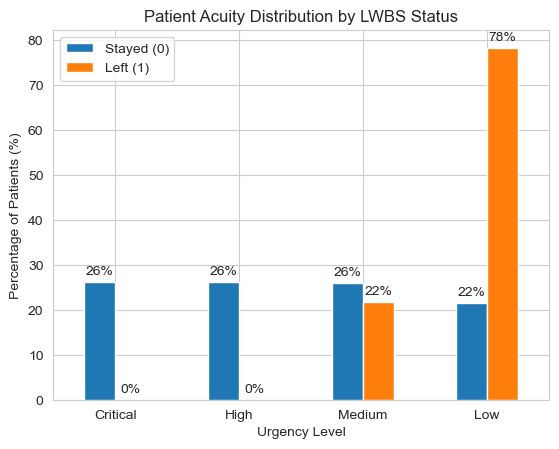

In [97]:
# Create normalized distribution of urgency levels within each LWBS group
acuity_summary = pd.crosstab(
    df["Urgency Level"],
    df["LWBS"],
    normalize="columns"
)

# Convert to percentage
acuity_summary = acuity_summary * 100

# Enforce logical clinical order
order = ["Critical", "High", "Medium", "Low"]
acuity_summary = acuity_summary.reindex(order)

# Plot side-by-side bar chart
ax = acuity_summary.plot(kind="bar")

plt.ylabel("Percentage of Patients (%)")
plt.xlabel("Urgency Level")
plt.title("Patient Acuity Distribution by LWBS Status")
plt.legend(["Stayed (0)", "Left (1)"])
plt.xticks(rotation=0)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", padding=3)

plt.show()

Patient acuity composition differs markedly between groups. Approximately **78% of LWBS encounters were classified as Low urgency**, compared to only **22% among patients who completed evaluation**. This suggests that lower-acuity patients are disproportionately affected by operational delays and may be more sensitive to extended waiting periods. The findings support the hypothesis that fast-track pathways for low-acuity patients could meaningfully reduce LWBS rates.

## 5. Risk Compounding & Interaction Effects
While individual operational factors such as triage delay and low-acuity classification are independently associated with LWBS, real-world departure behavior is likely influenced by overlapping risk conditions. In this section, we examine whether LWBS patients experience multiple simultaneous stressors, such as prolonged triage wait combined with low urgency classification or elevated staffing ratios. This analysis helps determine whether risk compounds across operational dimensions.

In [92]:
# Create risk flags
df["Long_Triage_Wait"] = (df["Time to Triage (min)"] > df["Time to Triage (min)"].median()).astype(int)
df["High_Nurse_Ratio"] = (df["Nurse-to-Patient Ratio"] > df["Nurse-to-Patient Ratio"].median()).astype(int)
df["Low_Urgency"] = df["Urgency Level"].eq("Low").astype(int)

# Count total risk factors per patient
df["Risk_Count"] = df[["Long_Triage_Wait", "High_Nurse_Ratio", "Low_Urgency"]].sum(axis=1)

# Compare average risk count
df.groupby("LWBS")["Risk_Count"].mean()

LWBS
0    1.139246
1    2.687747
Name: Risk_Count, dtype: float64

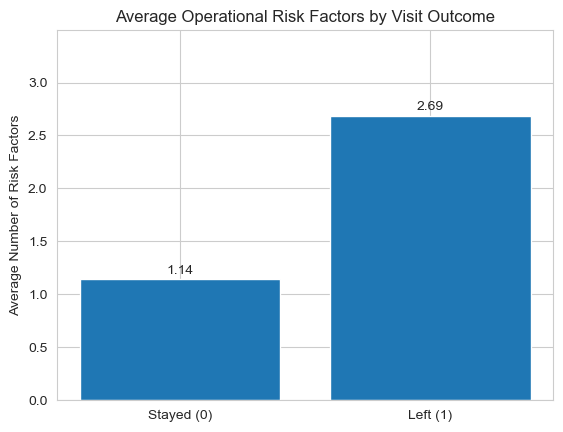

In [93]:
# Calculate averages
risk_avg = df.groupby("LWBS")["Risk_Count"].mean()

labels = ["Stayed (0)", "Left (1)"]
values = risk_avg.values

plt.figure()

bars = plt.bar(labels, values)

plt.title("Average Operational Risk Factors by Visit Outcome")
plt.ylabel("Average Number of Risk Factors")

# Add value labels
for i, v in enumerate(values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha="center")

plt.ylim(0, max(values) * 1.3)

plt.show()

LWBS patients exhibit more than double the average number of concurrent risk factors compared to patients who completed care (2.69 vs. 1.14). This indicates that departure behavior is rarely driven by a single operational issue. Instead, LWBS appears to emerge when multiple stressors—prolonged triage delay, higher nurse workload, and low-acuity classification—occur simultaneously. These findings support the need for a multivariable predictive model capable of identifying compounded risk in real time.

## 6. Predictive Modeling
Given the evidence of compounding operational risk factors, we now evaluate whether these variables can be combined into a predictive model capable of identifying high-risk encounters in real time.

In [94]:
df_model = df.copy()

# Drop period columns if they exist
df_model = df_model.drop(columns=[
    "Visit_Week",
    "Visit_Month",
    "Visit_Year"
], errors="ignore")

# Drop leakage columns if they exist
df_model = df_model.drop(columns=[
    "Total Wait Time (min)",
    "Time to Medical Professional (min)"
], errors="ignore")

# Drop identifier / non-model columns if they exist
df_model = df_model.drop(columns=[
    "Visit ID",
    "Patient ID",
    "Hospital ID",
    "Hospital Name",
    "Visit Date",
    "Patient Outcome"
], errors="ignore")

# Drop Visit_Day if it exists (prevents huge dummy expansion)
df_model = df_model.drop(columns=["Visit_Day"], errors="ignore")

# Build X and y
X = df_model.drop(columns=["LWBS"])
y = df_model["LWBS"]

# Convert boolean to int if column exists
if "Long_Triage_Wait" in X.columns:
    X["Long_Triage_Wait"] = X["Long_Triage_Wait"].astype(int)

# One-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver="liblinear", max_iter=2000)
model.fit(X_train, y_train)

# ROC-AUC
from sklearn.metrics import roc_auc_score
y_probs = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_probs)

print("ROC-AUC Score:", roc_auc)
print("X shape used:", X.shape)

ROC-AUC Score: 0.8671274393849794
X shape used: (5000, 34)


The logistic regression model achieved an **ROC-AUC of 0.87**, indicating strong discriminative ability. This means that when randomly selecting one LWBS encounter and one completed encounter, the model correctly ranks the LWBS case as higher risk approximately 87% of the time. Despite modest individual feature correlations (~0.30), the combined multivariable model captures meaningful operational signal. This confirms that LWBS risk is driven by interacting factors rather than a single dominant predictor.

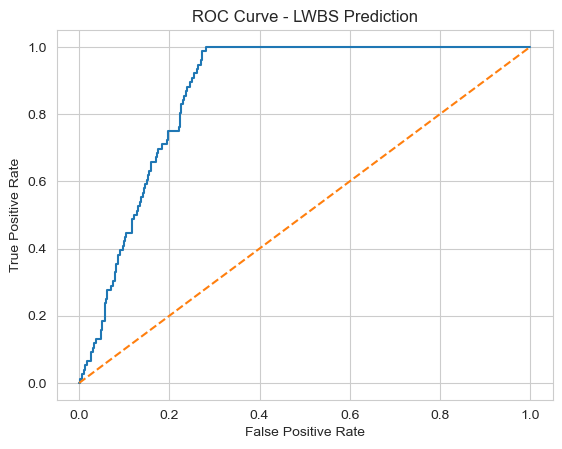

In [95]:
# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Plot
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LWBS Prediction")
plt.show()

The ROC curve illustrates the model’s ability to distinguish between patients who left without being seen (LWBS) and those who completed care. The curve lies well above the diagonal reference line, which represents random classification, indicating strong predictive performance.

With an ROC-AUC of approximately 0.87, the model demonstrates high discriminative ability. This means that when randomly selecting one LWBS encounter and one non-LWBS encounter, the model correctly assigns a higher predicted risk to the LWBS case about 87% of the time.

The steep initial rise of the curve suggests that the model achieves relatively high true positive rates while maintaining comparatively low false positive rates, which is desirable in operational risk prediction settings. Overall, the ROC analysis confirms that intake-stage operational variables provide meaningful signal for early LWBS risk identification.

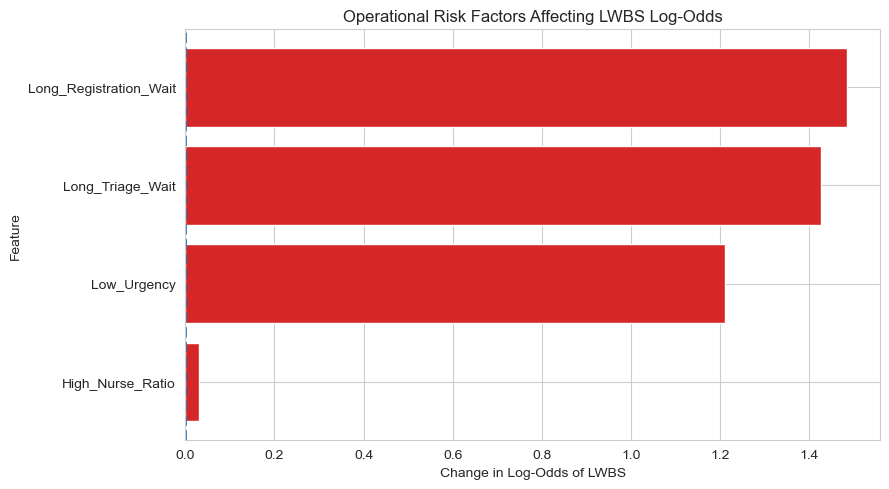

In [96]:
sns.set_style("whitegrid")

colors = coef_flags["Log_Odds"].apply(lambda x: "#d62728" if x > 0 else "#1f77b4")

plt.figure(figsize=(9, 5))
plt.barh(coef_flags["Feature"], coef_flags["Log_Odds"], color=colors)
plt.axvline(0, linestyle="--", linewidth=2)

plt.title("Operational Risk Factors Affecting LWBS Log-Odds")
plt.xlabel("Change in Log-Odds of LWBS")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The coefficient plot highlights the operational conditions most strongly associated with patients leaving without being seen. Prolonged registration and triage waits exhibit the largest positive effects on LWBS risk, suggesting that delays early in the intake process substantially increase patient abandonment. Low-acuity patients are also significantly more likely to leave, likely reflecting lower perceived urgency during extended waits. Higher nurse-to-patient ratios show a smaller but positive effect, indicating that staffing strain may contribute to throughput delays. These results reinforce earlier exploratory findings that cumulative intake delays are a primary driver of LWBS events.

## 7. Key predictors
The most influential predictors include prolonged triage delay, low urgency classification, and higher nurse-to-patient ratios. These findings reinforce exploratory insights, suggesting that staffing strain and intake bottlenecks significantly increase LWBS likelihood. Notably, urgency level remains a strong independent predictor even when controlling for operational timing variables, indicating that acuity-sensitive workflow design may be critical for mitigation strategies.

## 8. Operational Recommendations
Based on the findings, several operational strategies are recommended:

1. Implement fast-track protocols for low-acuity patients during high-volume hours.

2. Increase triage staffing during peak shift transition periods (e.g., 9 AM and 5 PM).

3. Deploy early LWBS risk scoring using intake variables to flag high-risk encounters.

4. Monitor cumulative intake delay thresholds to trigger operational adjustments.

These targeted interventions align directly with the model’s strongest predictive drivers.

## 9. Limitations & Future Work
This analysis is limited by the use of a simulated dataset and the absence of external socioeconomic or behavioral variables that may influence LWBS decisions. Additionally, while logistic regression provides interpretability, future work could evaluate non-linear models such as Random Forest or Gradient Boosting to potentially improve predictive performance. Prospective validation in a real-world emergency department setting would be required before operational deployment.

## 10. Conclusion & Buisness Impact
This analysis identified that LWBS is primarily driven by cumulative operational strain rather than a single bottleneck. Patients who left without being seen experienced more than double the average number of concurrent risk factors, including prolonged triage delay, low-acuity classification, and elevated nurse-to-patient ratios.

A logistic regression model integrating these operational and temporal features achieved an ROC-AUC of 0.87, demonstrating strong discriminative performance in identifying high-risk encounters. These results indicate that LWBS risk can be meaningfully predicted using intake-stage variables before provider evaluation.

Operationally, implementing fast-track pathways for low-acuity patients, reinforcing staffing during peak transition hours, and deploying real-time LWBS risk scoring could reasonably achieve the target 15% relative reduction in LWBS rates.

This project demonstrates how predictive analytics can move emergency department operations from reactive to proactive risk management.